<a href="https://colab.research.google.com/github/mandakini-15/NLP-Assignment/blob/main/nlp_assignment_1_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install requests pandas spacy nltk matplotlib wordcloud emoji contractions psaw
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 109.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Importing of the required Libraries

In [3]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, ne_chunk
from collections import Counter, defaultdict
import pandas as pd
import contractions
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
import emoji
import spacy
from nltk.tokenize import TweetTokenizer, word_tokenize #handles social text tokens like emoticons/lengthening
from nltk.stem import SnowballStemmer #Snowball for English stemming
warnings.filterwarnings('ignore')

# Download required NLTK data
print("Downloading NLTK resources...")
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('punkt_tab') # Added to fix the LookupError

nlp = spacy.load("en_core_web_sm")
tokenizer = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=False)   #preserves emoticons, reduces repeated letters, lowercases via preserve_case flag set False
stemmer = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


**Dataset Details:**

  **Dataset:** Sentiment140 dataset

  **Description:** It containing 1.6 million tweets preprocessed to remove emoticons and ready for sentiment analysis tasks, with labels of 0 (negative) or 4 (positive), ideal for training models to detect polarity in text.
   
  **Source:** Dataset has been downloaded from Kaggle

In [5]:
c = 'training.1600000.processed.noemoticon.csv' #the local path to dataset
cols = ['target','id','date','flag','user','text']
df = pd.read_csv(c, encoding='latin-1', names=cols, on_bad_lines='skip', engine='python') #reading with latin-1 to handle special characters; use column ordering from dataset
df = df.sample(n=20000, random_state=42).reset_index(drop=True)
df['text'] = df['text'].astype(str)

display(df.head(10))

,target,id,date,flag,user,text
0,4,1677996747,Sat May 02 05:02:29 PDT 2009,NO_QUERY,TenChiJin_,"Finished cleaning kitchen, corridor and living..."
1,0,2228794164,Thu Jun 18 14:53:42 PDT 2009,NO_QUERY,LAURENmcflyx,I'm too comfortable to go and get food... Plus...
2,0,2047944169,Fri Jun 05 14:25:10 PDT 2009,NO_QUERY,jmorell,Early night to be ready for #bikefest tomorrow...
3,0,1965273712,Fri May 29 15:37:49 PDT 2009,NO_QUERY,Belle128,So lathargic... Definitely need today to rest....
4,0,1966982198,Fri May 29 18:45:24 PDT 2009,NO_QUERY,freshprincess57,Watching the Bernie Mac show. Aww he was so fu...
5,0,2184596741,Mon Jun 15 16:08:25 PDT 2009,NO_QUERY,donturner182,Was going to get the podcast of WWDC on itunes...
6,0,2054135838,Sat Jun 06 06:38:51 PDT 2009,NO_QUERY,BBRRIITTTTYY,wish my dvd was here still gunna be ages away...
7,0,1676641719,Fri May 01 22:40:59 PDT 2009,NO_QUERY,MelissaWOOF,@louise__ sold out
8,0,1973646190,Sat May 30 11:33:25 PDT 2009,NO_QUERY,B0RR15,god sake. i have to wash up now. i'll be back ...
9,0,2175336125,Mon Jun 15 00:42:18 PDT 2009,NO_QUERY,AbbieBassett,I had the best weekend w/the fam. I don't wann...


**DATASET PREPARATION**
  

**Cleaning**

In [6]:
print("\n\n" + "="*80)
print("Cleaning")
print("="*80)

# Regex definitions
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r'@\w+') # remove @handles
HASHTAG_RE = re.compile(r"#(\w+)")
NON_ALPHANUM_RE = re.compile(r"[^a-zA-Z0-9\s]")
REPEATED_CHARS_RE = re.compile(r"(.)\1{2,}")
ASCII_EMOTICONS = re.compile(r"[:;=8][\-~]?[)(DPpOo/\\]|[)(DPpOo/\\][\-~]?[:;=8]")
PUNCTUATIONS = re.compile(r"[^\w\s]")

def clean_text(text, remove_emoji=True, remove_numbers=True, keep_hashtag_word=True):
    if not isinstance(text, str):
        return ""

    # Expand contractions
    text = contractions.fix(text)

    # Optionally remove emoji; to keep them use emoji.demojize(text)
    if remove_emoji:
        text = emoji.replace_emoji(text, replace='')
    # Remove URLs
    text = URL_RE.sub(" ", text)

    # Remove mentions (rare in YouTube comments but keep for generality)
    text = MENTION_RE.sub(" ", text)

    # Remove extra ASCII emoticons
    text =  ASCII_EMOTICONS.sub('', text)

    # Remove extra Puntuations
    text =  PUNCTUATIONS.sub('', text)

    # Normalize hashtags - keep the word following '#'
    if keep_hashtag_word:
        text = HASHTAG_RE.sub(r"\1", text)
    else:
        text = re.sub(r"#\w+", " ", text)

    # Remove numbers optionally
    if remove_numbers:
        text = re.sub(r"\d+", " ", text)

    # Remove non-alphanumeric (keep spaces)
    text = NON_ALPHANUM_RE.sub(" ", text)

    # Reduce long repeated chars: sooo -> soo
    text = REPEATED_CHARS_RE.sub(r"\1\1", text)

    # Lowercase
    text = text.lower()

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    #Tokenize
    tokens = word_tokenize(text)

    # Remove stop words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    return ' '.join(tokens)

# Apply cleaning
df['clean'] = df['text'].apply(clean_text)
print("Original -> Clean (sample):\n")
for i in range(min(5, len(df))):
    print("ORIG:", df.loc[i,'text'])
    print("CLEAN:", df.loc[i,'clean'])
    print("---")
df.head(5)



Cleaning
Original -> Clean (sample):

ORIG: Finished cleaning kitchen, corridor and living room.Teethbrushing right now and afterwards going to buy some toasts and juices.Keep going 
CLEAN: finished cleaning kitchen corridor living roomteethbrushing right afterwards going buy toasts juiceskeep going
---
ORIG: I'm too comfortable to go and get food... Plus it's too late to eat 
CLEAN: comfortable get food plus late eat
---
ORIG: Early night to be ready for #bikefest tomorrow. It's going to hurt, especially as we're a man down 
CLEAN: early night ready bikefest tomorrow going hurt especially man
---
ORIG: So lathargic... Definitely need today to rest. Sad bout havin to call out but mentally i needed to 
CLEAN: lathargic definitely need today rest sad bout havin call mentally needed
---
ORIG: Watching the Bernie Mac show. Aww he was so funny R.I.P Bernie Mac  http://myloc.me/22zF
CLEAN: watching bernie mac show aww funny rip bernie mac
---


,target,id,date,flag,user,text,clean
0,4,1677996747,Sat May 02 05:02:29 PDT 2009,NO_QUERY,TenChiJin_,"Finished cleaning kitchen, corridor and living...",finished cleaning kitchen corridor living room...
1,0,2228794164,Thu Jun 18 14:53:42 PDT 2009,NO_QUERY,LAURENmcflyx,I'm too comfortable to go and get food... Plus...,comfortable get food plus late eat
2,0,2047944169,Fri Jun 05 14:25:10 PDT 2009,NO_QUERY,jmorell,Early night to be ready for #bikefest tomorrow...,early night ready bikefest tomorrow going hurt...
3,0,1965273712,Fri May 29 15:37:49 PDT 2009,NO_QUERY,Belle128,So lathargic... Definitely need today to rest....,lathargic definitely need today rest sad bout ...
4,0,1966982198,Fri May 29 18:45:24 PDT 2009,NO_QUERY,freshprincess57,Watching the Bernie Mac show. Aww he was so fu...,watching bernie mac show aww funny rip bernie mac


**Normalization**

In [7]:
print("\n\n" + "="*80)
print("Normalization")
print("="*80)

lemmatizer = WordNetLemmatizer()

def normalize_text_lemm(text):
    """
    Normalize text using lemmatization and handle social media specifics
    """
    tokens = word_tokenize(text)

    # Lemmatization
    lemmatized = [lemmatizer.lemmatize(token, pos='v') for token in tokens]
    lemmatized = [lemmatizer.lemmatize(token, pos='n') for token in lemmatized]

    return ' '.join(lemmatized)

df['normalized_text_lemm'] = df['clean'].map(normalize_text_lemm)
df.head(5)

def normalize_text_stem(text):
    """
    Normalize text using stemming
    """
    return " ".join(stemmer.stem(tok) for tok in tokenizer.tokenize(text))

df['normalized_text_stem'] = df['clean'].map(normalize_text_stem)
df.head(5)



Normalization


,target,id,date,flag,user,text,clean,normalized_text_lemm,normalized_text_stem
0,4,1677996747,Sat May 02 05:02:29 PDT 2009,NO_QUERY,TenChiJin_,"Finished cleaning kitchen, corridor and living...",finished cleaning kitchen corridor living room...,finish clean kitchen corridor live roomteethbr...,finish clean kitchen corridor live roomteethbr...
1,0,2228794164,Thu Jun 18 14:53:42 PDT 2009,NO_QUERY,LAURENmcflyx,I'm too comfortable to go and get food... Plus...,comfortable get food plus late eat,comfortable get food plus late eat,comfort get food plus late eat
2,0,2047944169,Fri Jun 05 14:25:10 PDT 2009,NO_QUERY,jmorell,Early night to be ready for #bikefest tomorrow...,early night ready bikefest tomorrow going hurt...,early night ready bikefest tomorrow go hurt es...,earli night readi bikefest tomorrow go hurt es...
3,0,1965273712,Fri May 29 15:37:49 PDT 2009,NO_QUERY,Belle128,So lathargic... Definitely need today to rest....,lathargic definitely need today rest sad bout ...,lathargic definitely need today rest sad bout ...,latharg definit need today rest sad bout havin...
4,0,1966982198,Fri May 29 18:45:24 PDT 2009,NO_QUERY,freshprincess57,Watching the Bernie Mac show. Aww he was so fu...,watching bernie mac show aww funny rip bernie mac,watch bernie mac show aww funny rip bernie mac,watch berni mac show aww funni rip berni mac


**POS Tagging and Linguistic Exploration**

In [8]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

print("\n\n" + "="*80)
print("POS TAGGING AND LINGUISTIC EXPLORATION")
print("="*80)

# Apply POS tagging
def get_pos_tags(text):
    tokens = word_tokenize(text)
    return pos_tag(tokens)

df['pos_tags'] = df['text'].apply(get_pos_tags)


#Identify posts with specific POS tags
def analyze_pos_patterns(df):
    """Analyze POS patterns that affect tone and style"""

    # Count POS tags per post
    pos_analysis = []
    for idx, row in df.iterrows():
        pos_counts = Counter([tag for _, tag in row['pos_tags']])
        pos_analysis.append({
            'id': row['id'],
            'text': row['text'],
            'interjections': pos_counts.get('UH', 0),
            'adjectives': pos_counts.get('JJ', 0) + pos_counts.get('JJR', 0) + pos_counts.get('JJS', 0),
            'pronouns': pos_counts.get('PRP', 0) + pos_counts.get('PRP$', 0),
            'adverbs': pos_counts.get('RB', 0) + pos_counts.get('RBR', 0) + pos_counts.get('RBS', 0)
        })

    return pd.DataFrame(pos_analysis)

pos_df = analyze_pos_patterns(df)

df.head(5)

print("Posts with HIGH ADJECTIVE usage (emotional/descriptive tone):")
high_adj = pos_df.nlargest(3, 'adjectives')
for _, row in high_adj.iterrows():
    print(f"\nPost #{row['id']} - {row['adjectives']} adjectives")
    print(f"Text: {row['text'][:100]}...")
    tags = df[df['id'] == row['id']]['pos_tags'].values[0]
    adjs = [word for word, tag in tags if tag.startswith('JJ')]
    print(f"Adjectives: {', '.join(adjs)}")

print("Posts with HIGH PRONOUN usage (personal/subjective tone):")
high_pron = pos_df.nlargest(3, 'pronouns')
for _, row in high_pron.iterrows():
    print(f"\nPost #{row['id']} - {row['pronouns']} pronouns")
    print(f"Text: {row['text'][:100]}...")
    tags = df[df['id'] == row['id']]['pos_tags'].values[0]
    prons = [word for word, tag in tags if tag in ['PRP', 'PRP$']]
    print(f"Pronouns: {', '.join(prons)}")

#Syntactic patterns analysis
def extract_syntactic_patterns(df):
    """Extract common syntactic patterns"""

    adj_noun = []
    verb_obj = []
    pron_verb = []

    for idx, row in df.iterrows():
        tags = row['pos_tags']

        for i in range(len(tags) - 1):
            word1, tag1 = tags[i]
            word2, tag2 = tags[i+1]

            # Adjective-Noun pairs
            if tag1.startswith('JJ') and tag2.startswith('NN'):
                adj_noun.append(f"{word1} {word2}")

            # Verb-Object pairs (simplified)
            if tag1.startswith('VB') and tag2.startswith('NN'):
                verb_obj.append(f"{word1} {word2}")

            # Pronoun-Verb combinations
            if tag1 in ['PRP', 'PRP$'] and tag2.startswith('VB'):
                pron_verb.append(f"{word1} {word2}")

    return adj_noun, verb_obj, pron_verb

adj_noun, verb_obj, pron_verb = extract_syntactic_patterns(df)

print("ADJECTIVE-NOUN PAIRS (descriptive expressions):")
adj_noun_counts = Counter(adj_noun).most_common(10)
for pattern, count in adj_noun_counts:
    print(f"  • '{pattern}' - {count} occurrences")

print("VERB-OBJECT PAIRS (action-oriented language):")
verb_obj_counts = Counter(verb_obj).most_common(10)
for pattern, count in verb_obj_counts:
    print(f"  • '{pattern}' - {count} occurrences")

print("PRONOUN-VERB COMBINATIONS (personal expressions):")
pron_verb_counts = Counter(pron_verb).most_common(10)
for pattern, count in pron_verb_counts:
    print(f"  • '{pattern}' - {count} occurrences")

#Discussion on informal language patterns
print("""
LINGUISTIC OBSERVATIONS:

1. INFORMAL & CONVERSATIONAL CHARACTERISTICS:
   • High pronoun usage ('I', 'we', 'our') indicates personal stance and opinions
   • Emotional adjectives ('devastating', 'amazing', 'ridiculous') reveal sentiment
   • Imperative verbs ('act', 'invest', 'learn') show call-to-action patterns
   • Exclamation patterns and repeated punctuation emphasize urgency

2. IMPACT ON NLP TASKS:

   STANCE DETECTION:
   - Pronoun-verb patterns (e.g., 'we need', 'I believe') signal personal stance
   - Modal verbs ('must', 'should', 'can') indicate opinion strength
   - Adjective intensity reveals stance polarity and confidence

   TOXICITY DETECTION:
   - Question patterns with negative adjectives ('Why is...not doing?')
   - Adverbs of intensity ('absolutely', 'still', 'just') amplify emotion
   - All-caps words and repeated punctuation signal aggression/frustration

   SARCASM DETECTION:
   - Adjective-noun mismatches (positive adj + negative context)
   - Ellipsis usage and informal punctuation patterns
   - Pronoun usage in rhetorical questions indicates irony

3. SOCIAL MEDIA SPECIFIC PATTERNS:
   • Hashtags function as topic markers and opinion amplifiers
   • Mentions direct sentiment toward entities (organizations, people)
   • URL presence correlates with informative vs. opinion-based posts
   • Emoticons and repeated characters signal informal, emotional tone
""")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.




POS TAGGING AND LINGUISTIC EXPLORATION
Posts with HIGH ADJECTIVE usage (emotional/descriptive tone):

Post #1989530880 - 9 adjectives
Text: @yovazukhrufa thx yova, no prob! @zanetamelia thx net, no i didnt  @camshaq haha, okay. thx cam! @al...
Adjectives: @, zanetamelia, thx, @, thx, @, alyshachandra, @, adyota

Post #2249950605 - 9 adjectives
Text: @abbylatip u-huh ... sorry i ddnt read ur skype. soalnya i makan kelamaan  heheh.. i'll try to b onl...
Adjectives: @, abbylatip, u-huh, i, ur, i, kelamaan, online, i

Post #1753616078 - 8 adjectives
Text: @ddlovato I missed u. Stop defending urself. Your true fans are with u  U're the best. And for me u ...
Adjectives: @, u, true, u, best, u, biggest, french
Posts with HIGH PRONOUN usage (personal/subjective tone):

Post #1754157188 - 10 pronouns
Text: Hmmm, I miss my mom now  I did love that woman. She adopted me - loved me and raised me as her own. ...
Pronouns: I, my, I, She, me, me, me, her, She, her

Post #1968097839 - 9 pronouns
Te

**VISUALIZATION**

Visualizations saved as 'pos_visualizations.png'


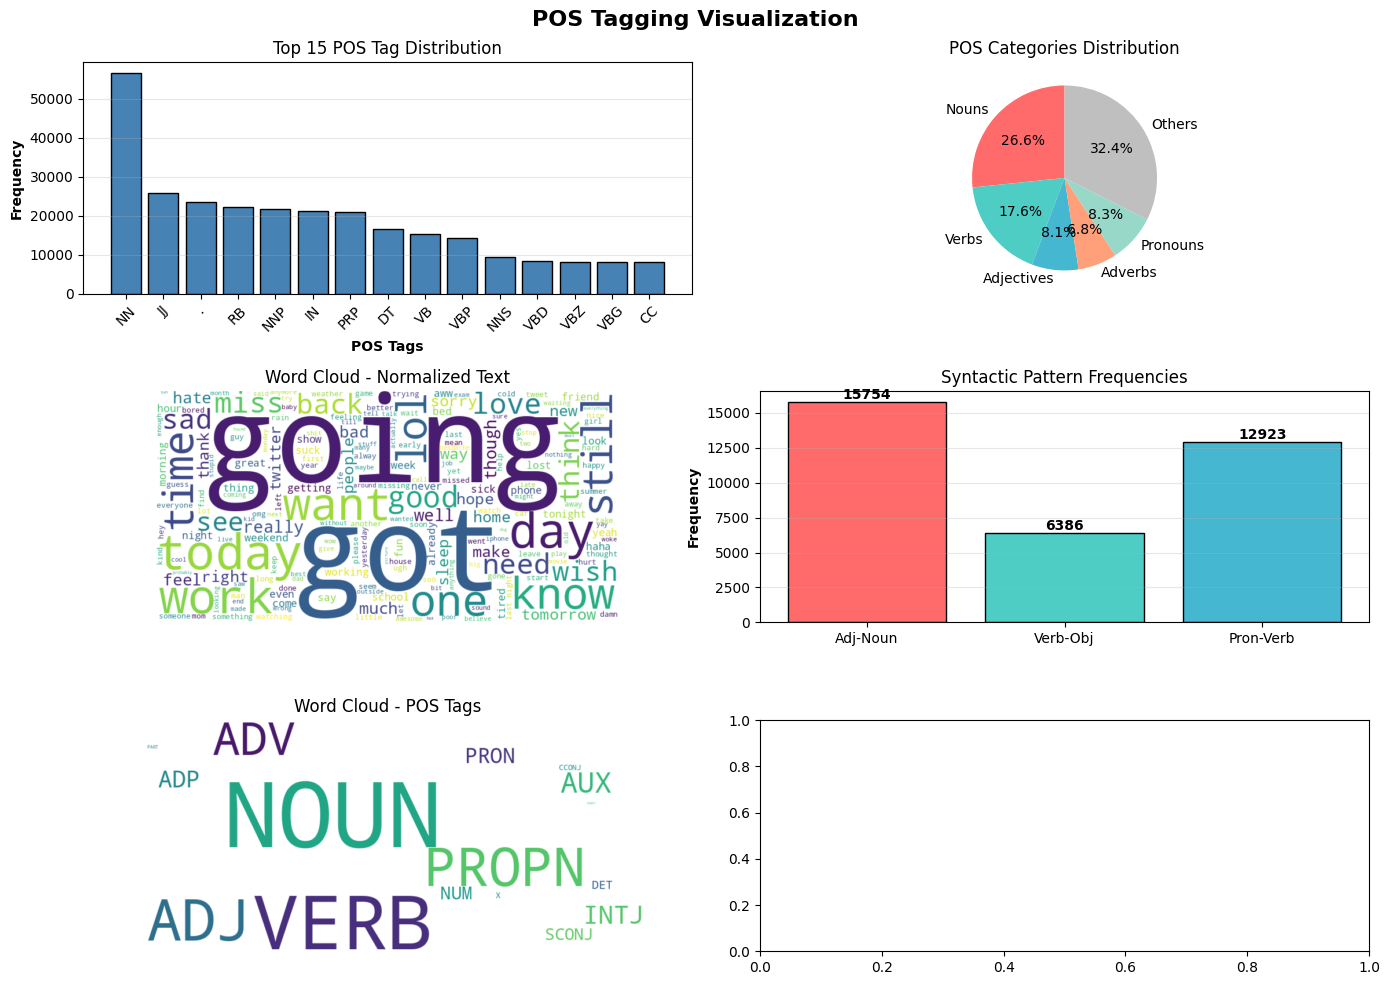

In [11]:
# Collect all POS tags
all_pos_tags = []
for tags in df['pos_tags']:
    all_pos_tags.extend([tag for _, tag in tags])

pos_counts = Counter(all_pos_tags)

# Create visualizations
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('POS Tagging Visualization', fontsize=16, fontweight='bold')

#Bar chart of POS distribution
ax1 = axes[0, 0]
top_pos = dict(pos_counts.most_common(15))
ax1.bar(top_pos.keys(), top_pos.values(), color='steelblue', edgecolor='black')
ax1.set_xlabel('POS Tags', fontweight='bold')
ax1.set_ylabel('Frequency', fontweight='bold')
ax1.set_title('Top 15 POS Tag Distribution')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

#POS category grouping
ax2 = axes[0, 1]
pos_categories = {
    'Nouns': sum([pos_counts[tag] for tag in pos_counts if tag.startswith('NN')]),
    'Verbs': sum([pos_counts[tag] for tag in pos_counts if tag.startswith('VB')]),
    'Adjectives': sum([pos_counts[tag] for tag in pos_counts if tag.startswith('JJ')]),
    'Adverbs': sum([pos_counts[tag] for tag in pos_counts if tag.startswith('RB')]),
    'Pronouns': sum([pos_counts[tag] for tag in pos_counts if tag in ['PRP', 'PRP$']]),
    'Others': sum([count for tag, count in pos_counts.items() if not any(tag.startswith(x) for x in ['NN', 'VB', 'JJ', 'RB']) and tag not in ['PRP', 'PRP$']])
}
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#BFBFBF']
ax2.pie(pos_categories.values(), labels=pos_categories.keys(), autopct='%1.1f%%',
        colors=colors_pie, startangle=90)
ax2.set_title('POS Categories Distribution')

#Word cloud from normalized text
ax_normal_wc = axes[1, 0] # Renamed ax3 to avoid confusion with the subsequent overwrite
all_text_normal = ' '.join(df['clean'])
wordcloud_normal = WordCloud(width=800, height=400, background_color='white',colormap='viridis').generate(all_text_normal)
ax_normal_wc.imshow(wordcloud_normal, interpolation='bilinear')
ax_normal_wc.axis('off')
ax_normal_wc.set_title('Word Cloud - Normalized Text')

#Word cloud from pos_tag
pc = Counter() # This Counter is populated by Spacy POS tags from 'clean' text
for txt in df['clean'].astype(str):
    d = nlp(txt)
    for tok in d:
        pc[tok.pos_] += 1

# pos_df is created from pc, but not directly used by generate_from_frequencies
pos_df = pd.DataFrame(pc.items(), columns=['POS','count']).sort_values('count', ascending=False)

# Use the same subplot axes[1,0] for the POS tag word cloud, overwriting the previous one.
ax_pos_wc = axes[2, 0] # Renamed ax3 for clarity

# Generate word cloud from the frequencies in 'pc'
wordcloud_postags = WordCloud(width=900, height=400, background_color='white', collocations=False).generate_from_frequencies(pc)
ax_pos_wc.imshow(wordcloud_postags, interpolation='bilinear')
ax_pos_wc.axis('off')
ax_pos_wc.set_title('Word Cloud - POS Tags')

#Syntactic pattern frequency
ax4 = axes[1, 1]
pattern_types = ['Adj-Noun', 'Verb-Obj', 'Pron-Verb']
pattern_counts = [len(adj_noun), len(verb_obj), len(pron_verb)]
colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax4.bar(pattern_types, pattern_counts, color=colors_bar, edgecolor='black')
ax4.set_ylabel('Frequency', fontweight='bold')
ax4.set_title('Syntactic Pattern Frequencies')
ax4.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('pos_visualizations.png', dpi=300, bbox_inches='tight')
print("Visualizations saved as 'pos_visualizations.png'")